# FreshRetailNet-50K — Análisis Exploratorio de Datos (EDA)

**Dataset:** [Dingdong-Inc/FreshRetailNet-50K](https://huggingface.co/datasets/Dingdong-Inc/FreshRetailNet-50K)  
**Descripción:** Primer benchmark a gran escala para estimación de demanda censurada en retail de productos frescos.  
- 50,000 series temporales de 90 días (producto-tienda)
- 898 tiendas en 18 ciudades
- 865 SKUs perecederos
- ~20% de datos con desabastecimiento orgánico

---

## 1. Instalación e Importación de Librerías

In [ ]:
# Instalación de dependencias (ejecutar una sola vez)
!pip install datasets pandas numpy matplotlib seaborn scipy scikit-learn missingno -q

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import missingno as msno
from scipy import stats
from scipy.stats import skew, kurtosis, pearsonr, spearmanr
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Configuración visual
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('husl')
sns.set_style('whitegrid')

SEED = 42
np.random.seed(SEED)

print('Librerías cargadas correctamente')

Librerías cargadas correctamente


## 2. Carga del Dataset

In [ ]:
from datasets import load_dataset

print('Cargando dataset desde HuggingFace...')
dataset = load_dataset('Dingdong-Inc/FreshRetailNet-50K')
print(dataset)
print('\nDataset cargado!')

Cargando dataset desde HuggingFace...


README.md: 0.00B [00:00, ?B/s]

data/train.parquet:   0%|          | 0.00/106M [00:00<?, ?B/s]

data/eval.parquet:   0%|          | 0.00/8.44M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/4500000 [00:00<?, ? examples/s]

Generating eval split:   0%|          | 0/350000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['city_id', 'store_id', 'management_group_id', 'first_category_id', 'second_category_id', 'third_category_id', 'product_id', 'dt', 'sale_amount', 'hours_sale', 'stock_hour6_22_cnt', 'hours_stock_status', 'discount', 'holiday_flag', 'activity_flag', 'precpt', 'avg_temperature', 'avg_humidity', 'avg_wind_level'],
        num_rows: 4500000
    })
    eval: Dataset({
        features: ['city_id', 'store_id', 'management_group_id', 'first_category_id', 'second_category_id', 'third_category_id', 'product_id', 'dt', 'sale_amount', 'hours_sale', 'stock_hour6_22_cnt', 'hours_stock_status', 'discount', 'holiday_flag', 'activity_flag', 'precpt', 'avg_temperature', 'avg_humidity', 'avg_wind_level'],
        num_rows: 350000
    })
})

Dataset cargado!


In [ ]:
# Convertir a DataFrames
# Usamos una muestra del train para el análisis exploratorio (el dataset completo es muy grande)
SAMPLE_SIZE = 100_000  # Ajustar según memoria disponible

print(f'Convirtiendo train split a DataFrame (muestra de {SAMPLE_SIZE:,} filas)...')
df_train = dataset['train'].select(range(SAMPLE_SIZE)).to_pandas()

print(f'Convirtiendo eval split a DataFrame...')
df_eval = dataset['eval'].to_pandas()

print(f'\nShapes:')
print(f'   Train (muestra): {df_train.shape}')
print(f'   Eval:            {df_eval.shape}')

# Trabajamos principalmente con train
df = df_train.copy()

Convirtiendo train split a DataFrame (muestra de 100,000 filas)...
Convirtiendo eval split a DataFrame...

Shapes:
   Train (muestra): (100000, 19)
   Eval:            (350000, 19)


In [ ]:
# Convertir fecha a datetime
df['dt'] = pd.to_datetime(df['dt'])
df_eval['dt'] = pd.to_datetime(df_eval['dt'])

# Extraer features temporales
df['day_of_week'] = df['dt'].dt.dayofweek
df['month'] = df['dt'].dt.month
df['week'] = df['dt'].dt.isocalendar().week.astype(int)
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)

# Calcular stock-out rate
df['stockout_rate'] = df['stock_hour6_22_cnt'] / 16  # 16 horas entre 6-22
df['has_stockout'] = (df['stock_hour6_22_cnt'] > 0).astype(int)
df['has_discount'] = (df['discount'] < 1.0).astype(int)

print('Features temporales y derivadas creadas')
print(f'Rango de fechas: {df["dt"].min().date()} → {df["dt"].max().date()}')

Features temporales y derivadas creadas
Rango de fechas: 2024-03-28 → 2024-06-25


---
## 3. Descripción General del Dataset

In [ ]:
print('='*70)
print('DESCRIPCIÓN GENERAL DEL DATASET')
print('='*70)
print(f'\nDimensiones:    {df.shape[0]:,} filas × {df.shape[1]} columnas')
print(f'\nCiudades únicas: {df["city_id"].nunique()}')
print(f'Tiendas únicas:  {df["store_id"].nunique()}')
print(f'Productos únicos:{df["product_id"].nunique()}')
print(f'Fechas únicas:   {df["dt"].nunique()}')
print(f'Desde: {df["dt"].min().date()}')
print(f'Hasta: {df["dt"].max().date()}')
print(f'\nMemoria RAM usada: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB')

DESCRIPCIÓN GENERAL DEL DATASET

Dimensiones:    100,000 filas × 26 columnas

Ciudades únicas: 1
Tiendas únicas:  13
Productos únicos:273
Fechas únicas:   90
Desde: 2024-03-28
Hasta: 2024-06-25

Memoria RAM usada: 41.2 MB


In [ ]:
import numpy as np
# Tipos de datos
print('\nTIPOS DE DATOS POR COLUMNA:')
print('-'*50)
scalar_cols = [c for c in df.columns if not isinstance(df[c].iloc[0], (list, np.ndarray))]
nunique_series = df[scalar_cols].nunique()
for col in df.columns:
    if col not in scalar_cols:
        nunique_series.loc[col] = 'N/A (sequence)'

nunique_series = nunique_series.reindex(df.columns)

type_info = pd.DataFrame({
    'Tipo': df.dtypes,
    'Valores únicos': nunique_series,
    'Nulos': df.isnull().sum(),
    '% Nulos': (df.isnull().sum() / len(df) * 100).round(2)
})
print(type_info.to_string())


TIPOS DE DATOS POR COLUMNA:
--------------------------------------------------
                               Tipo  Valores únicos  Nulos  % Nulos
city_id                       int64               1      0      0.0
store_id                      int64              13      0      0.0
management_group_id           int64               7      0      0.0
first_category_id             int64              25      0      0.0
second_category_id            int64              64      0      0.0
third_category_id             int64             150      0      0.0
product_id                    int64             273      0      0.0
dt                   datetime64[ns]              90      0      0.0
sale_amount                 float64             327      0      0.0
hours_sale                   object  N/A (sequence)      0      0.0
stock_hour6_22_cnt            int32              17      0      0.0
hours_stock_status           object  N/A (sequence)      0      0.0
discount                    float64 

In [ ]:
# Primeras filas (columnas escalares, sin listas)
scalar_cols = [c for c in df.columns if not isinstance(df[c].iloc[0], (list, np.ndarray))]
df[scalar_cols].head(5)

,city_id,store_id,management_group_id,first_category_id,second_category_id,third_category_id,product_id,dt,sale_amount,stock_hour6_22_cnt,...,avg_temperature,avg_humidity,avg_wind_level,day_of_week,month,week,is_weekend,stockout_rate,has_stockout,has_discount
0,0,0,0,5,6,65,38,2024-03-28,0.1,0,...,15.48,73.54,1.97,3,3,13,0,0.0000,0,0
1,0,0,0,5,6,65,38,2024-03-29,0.1,1,...,15.08,76.56,1.71,4,3,13,0,0.0625,1,0
2,0,0,0,5,6,65,38,2024-03-30,0.0,0,...,15.91,76.47,1.73,5,3,13,1,0.0000,0,0
3,0,0,0,5,6,65,38,2024-03-31,0.1,11,...,16.13,77.40,1.76,6,3,13,1,0.6875,1,0
4,0,0,0,5,6,65,38,2024-04-01,0.2,8,...,15.37,78.26,1.25,0,4,14,0,0.5000,1,0


In [ ]:
# Estadísticas descriptivas numéricas
num_cols = ['sale_amount', 'stock_hour6_22_cnt', 'discount',
            'holiday_flag', 'activity_flag', 'precpt',
            'avg_temperature', 'avg_humidity', 'avg_wind_level']

desc = df[num_cols].describe().T
desc['skewness'] = df[num_cols].apply(lambda x: skew(x.dropna()))
desc['kurtosis'] = df[num_cols].apply(lambda x: kurtosis(x.dropna()))
print('\nESTADÍSTICAS DESCRIPTIVAS:')
desc.round(4)


ESTADÍSTICAS DESCRIPTIVAS:


,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
sale_amount,100000.0,1.0320,1.1872,0.0000,0.4000,0.7000,1.2000,22.9000,3.9996,26.9663
stock_hour6_22_cnt,100000.0,3.1504,4.4585,0.0000,0.0000,0.0000,6.0000,16.0000,1.2936,0.6129
discount,100000.0,0.9146,0.1136,0.3580,0.8510,0.9880,1.0000,1.0000,-1.3606,1.2622
holiday_flag,100000.0,0.3445,0.4752,0.0000,0.0000,0.0000,1.0000,1.0000,0.6546,-1.5714
activity_flag,100000.0,0.3990,0.4897,0.0000,0.0000,0.0000,1.0000,1.0000,0.4123,-1.8300
precpt,100000.0,3.1430,2.9828,0.2112,1.4168,2.0875,3.2152,15.5666,1.9814,3.4363
avg_temperature,100000.0,21.5411,3.5161,14.3200,18.3900,21.7900,24.0600,28.7200,0.0073,-1.0510
avg_humidity,100000.0,74.2154,5.2160,62.8000,70.2600,74.4500,77.5000,87.0500,-0.0047,-0.5013
avg_wind_level,100000.0,1.6236,0.2492,1.0400,1.4600,1.6200,1.7700,2.6100,0.4073,0.3210


In [ ]:
print('\nMEDIANAS DE COLUMNAS NUMÉRICAS:')
print('-'*50)
print(df[num_cols].median().to_string())


MEDIANAS DE COLUMNAS NUMÉRICAS:
--------------------------------------------------
sale_amount            0.7000
stock_hour6_22_cnt     0.0000
discount               0.9880
holiday_flag           0.0000
activity_flag          0.0000
precpt                 2.0875
avg_temperature       21.7900
avg_humidity          74.4500
avg_wind_level         1.6200


---
## 4. Análisis de Valores Faltantes y Atípicos

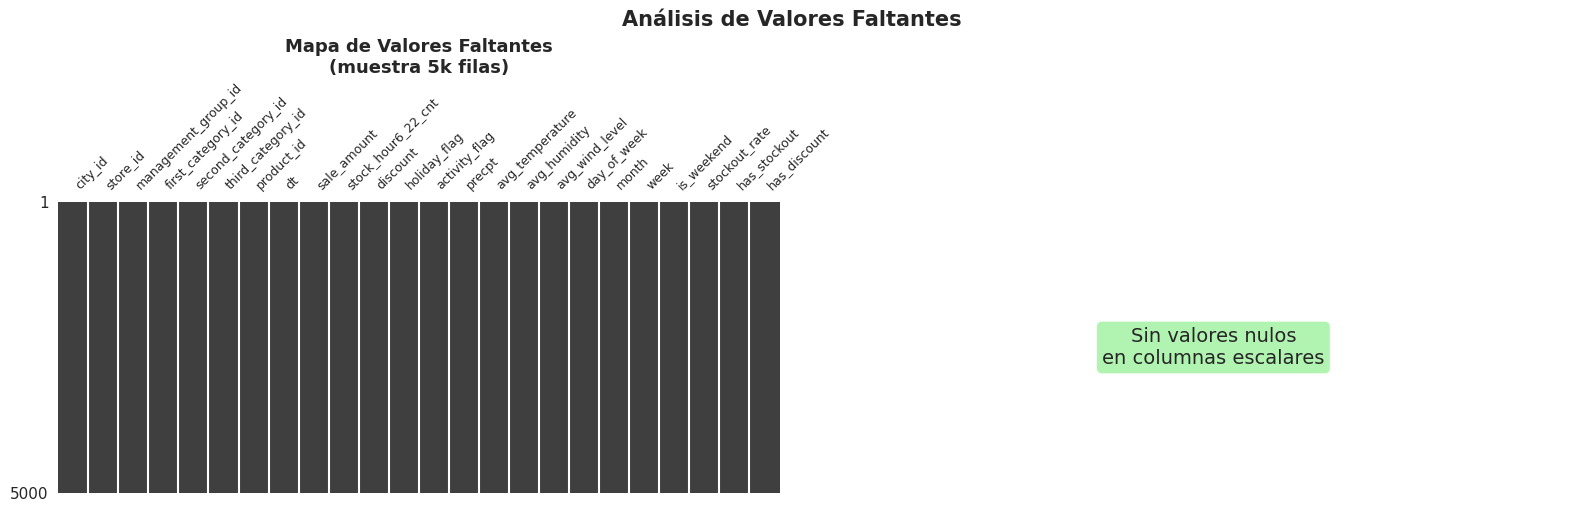


Resumen:
Sin valores nulos detectados


In [ ]:
# ---- 4.1 Valores Faltantes ----
missing = df[scalar_cols].isnull().sum()
missing_pct = (missing / len(df) * 100).round(3)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Heatmap de nulos
ax = axes[0]
msno.matrix(df[scalar_cols].sample(min(5000, len(df)), random_state=SEED),
            ax=ax, sparkline=False, fontsize=9)
ax.set_title('Mapa de Valores Faltantes\n(muestra 5k filas)', fontsize=13, fontweight='bold')

# Barras de nulos
ax2 = axes[1]
cols_with_nulls = missing_pct[missing_pct > 0]
if len(cols_with_nulls) == 0:
    ax2.text(0.5, 0.5, 'Sin valores nulos\nen columnas escalares',
             ha='center', va='center', fontsize=14, transform=ax2.transAxes,
             bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.7))
    ax2.axis('off')
else:
    cols_with_nulls.plot(kind='barh', ax=ax2, color='coral')
    ax2.set_xlabel('% Nulos')
    ax2.set_title('Columnas con Valores Faltantes')

plt.tight_layout()
plt.suptitle('Análisis de Valores Faltantes', fontsize=15, fontweight='bold', y=1.02)
plt.savefig('01_missing_values.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'\nResumen:\n{missing_pct[missing_pct > 0].to_string() if missing_pct[missing_pct > 0].any() else "Sin valores nulos detectados"}')

In [ ]:
# ---- 4.2 Detección de Outliers con IQR y Z-score ----
outlier_cols = ['sale_amount', 'stock_hour6_22_cnt', 'precpt',
                'avg_temperature', 'avg_humidity', 'avg_wind_level', 'discount']

outlier_report = []
for col in outlier_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_iqr = ((df[col] < lower) | (df[col] > upper)).sum()

    z_scores = np.abs(stats.zscore(df[col].dropna()))
    n_z = (z_scores > 3).sum()

    outlier_report.append({
        'Columna': col,
        'Min': df[col].min(),
        'Max': df[col].max(),
        'IQR_Lower': round(lower, 3),
        'IQR_Upper': round(upper, 3),
        'Outliers_IQR': n_iqr,
        'Outliers_IQR_%': round(n_iqr / len(df) * 100, 2),
        'Outliers_Z>3': n_z,
        'Outliers_Z_%': round(n_z / len(df) * 100, 2),
    })

df_outliers = pd.DataFrame(outlier_report).set_index('Columna')
print('\nREPORTE DE OUTLIERS:')
df_outliers


REPORTE DE OUTLIERS:


,Min,Max,IQR_Lower,IQR_Upper,Outliers_IQR,Outliers_IQR_%,Outliers_Z>3,Outliers_Z_%
Columna,,,,,,,,
sale_amount,0.0000,22.9000,-0.800,2.400,7917,7.92,2313,2.31
stock_hour6_22_cnt,0.0000,16.0000,-9.000,15.000,2690,2.69,0,0.00
precpt,0.2112,15.5666,-1.281,5.913,14474,14.47,3371,3.37
avg_temperature,14.3200,28.7200,9.885,32.565,0,0.00,0,0.00
avg_humidity,62.8000,87.0500,59.400,88.360,0,0.00,0,0.00
avg_wind_level,1.0400,2.6100,0.995,2.235,1619,1.62,483,0.48
discount,0.3580,1.0000,0.628,1.224,3350,3.35,1393,1.39


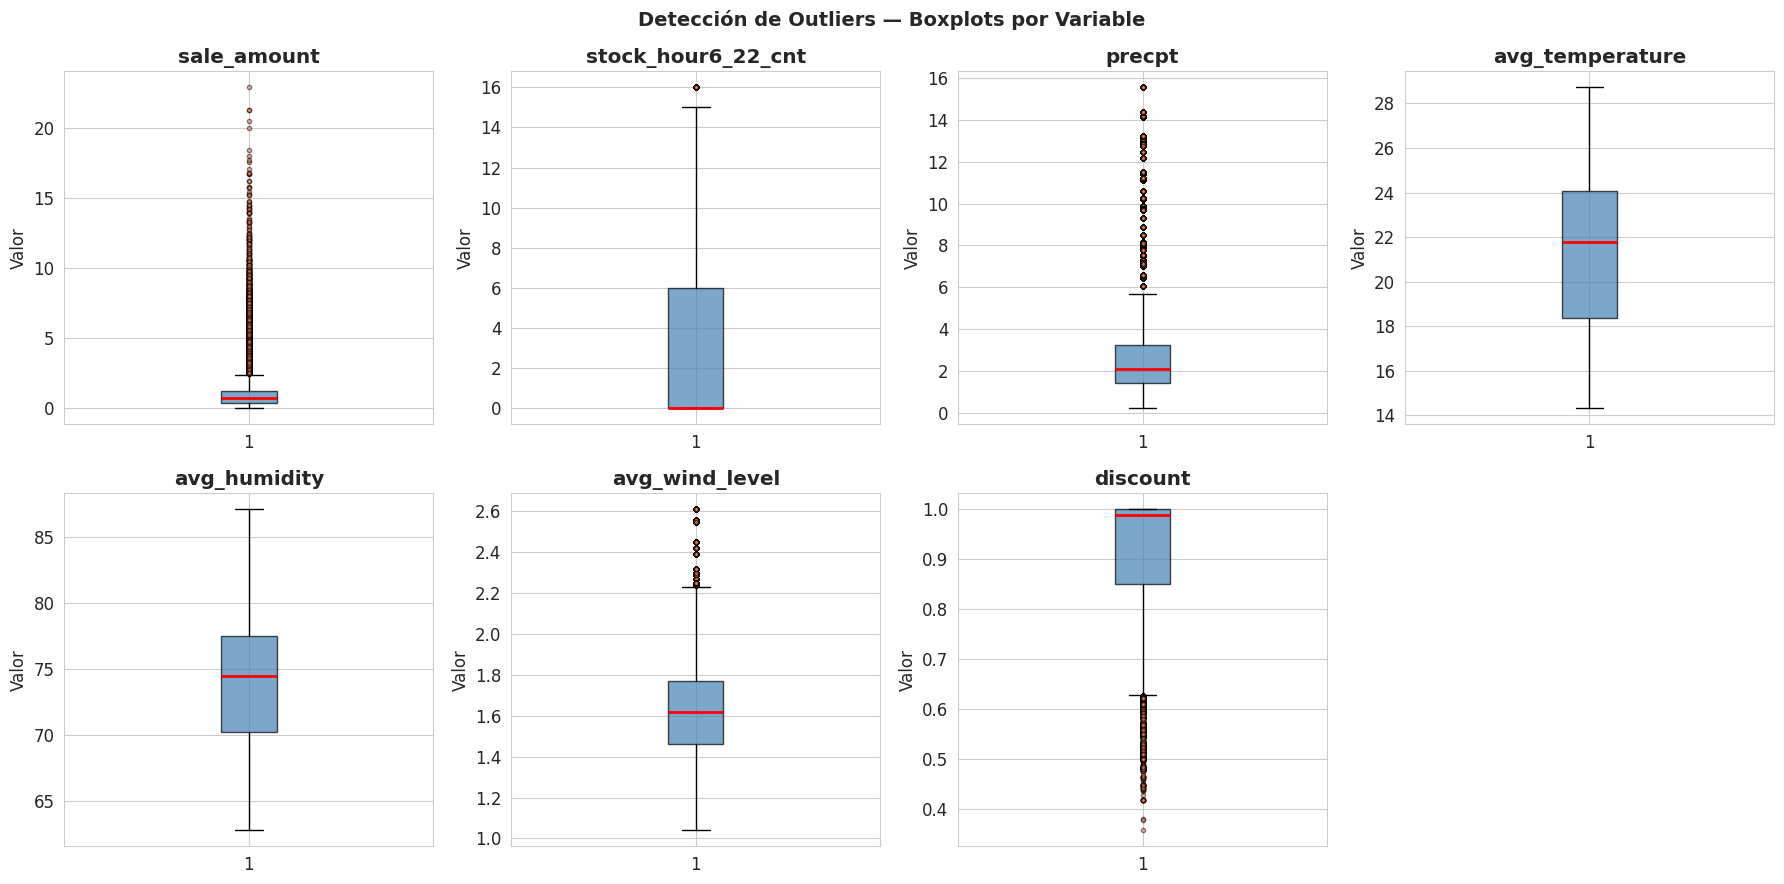

In [ ]:
# Boxplots para visualizar outliers
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for i, col in enumerate(outlier_cols):
    axes[i].boxplot(df[col].dropna(), vert=True, patch_artist=True,
                   boxprops=dict(facecolor='steelblue', alpha=0.7),
                   medianprops=dict(color='red', linewidth=2),
                   flierprops=dict(marker='o', markerfacecolor='coral', markersize=3, alpha=0.5))
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_ylabel('Valor')

axes[-1].axis('off')
plt.suptitle('Detección de Outliers — Boxplots por Variable', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('02_outliers_boxplots.png', dpi=120, bbox_inches='tight')
plt.show()

Skewness: 4.000
Kurtosis: 26.966
Pct de ceros: 3.2%


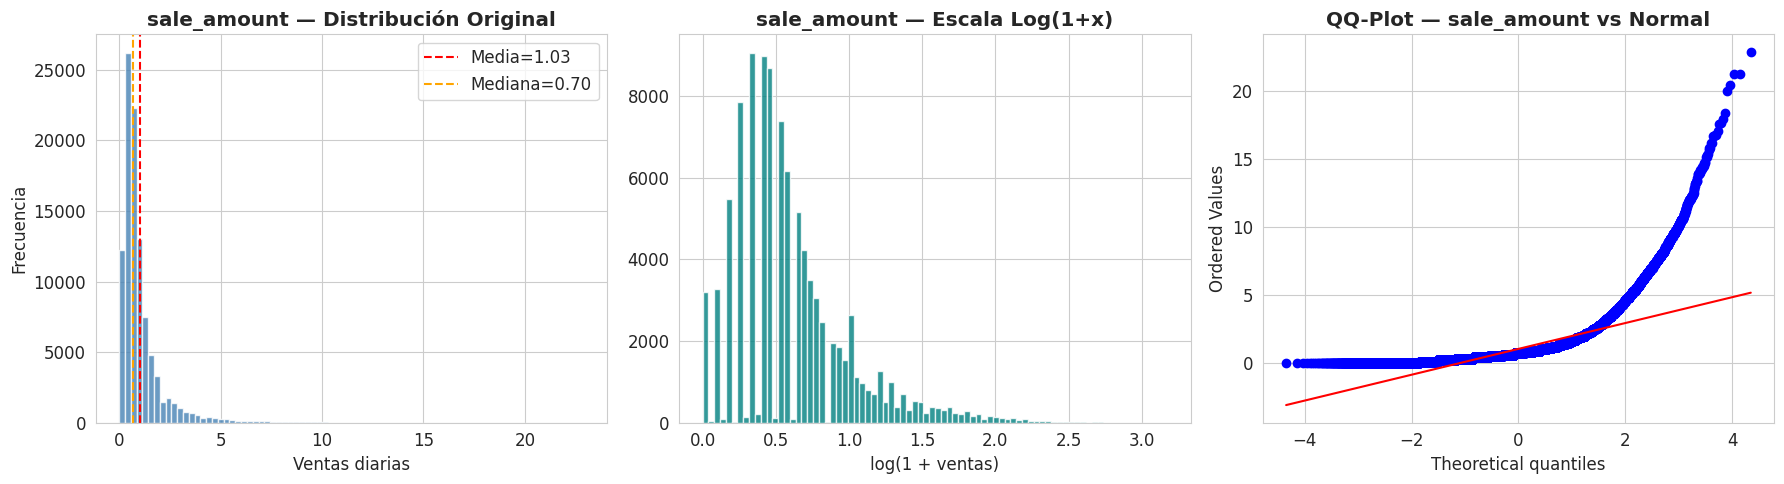

In [ ]:
# Análisis especial de sale_amount (variable objetivo)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Distribución original
axes[0].hist(df['sale_amount'], bins=80, color='steelblue', alpha=0.8, edgecolor='white')
axes[0].set_title('sale_amount — Distribución Original', fontweight='bold')
axes[0].set_xlabel('Ventas diarias')
axes[0].set_ylabel('Frecuencia')
axes[0].axvline(df['sale_amount'].mean(), color='red', linestyle='--', label=f'Media={df["sale_amount"].mean():.2f}')
axes[0].axvline(df['sale_amount'].median(), color='orange', linestyle='--', label=f'Mediana={df["sale_amount"].median():.2f}')
axes[0].legend()

# Log transform
log_sales = np.log1p(df['sale_amount'])
axes[1].hist(log_sales, bins=80, color='teal', alpha=0.8, edgecolor='white')
axes[1].set_title('sale_amount — Escala Log(1+x)', fontweight='bold')
axes[1].set_xlabel('log(1 + ventas)')

# QQ-plot
stats.probplot(df['sale_amount'].dropna(), dist='norm', plot=axes[2])
axes[2].set_title('QQ-Plot — sale_amount vs Normal', fontweight='bold')

print(f'Skewness: {skew(df["sale_amount"].dropna()):.3f}')
print(f'Kurtosis: {kurtosis(df["sale_amount"].dropna()):.3f}')
print(f'Pct de ceros: {(df["sale_amount"]==0).mean()*100:.1f}%')

plt.tight_layout()
plt.savefig('03_sale_amount_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 5. Análisis Distributivo

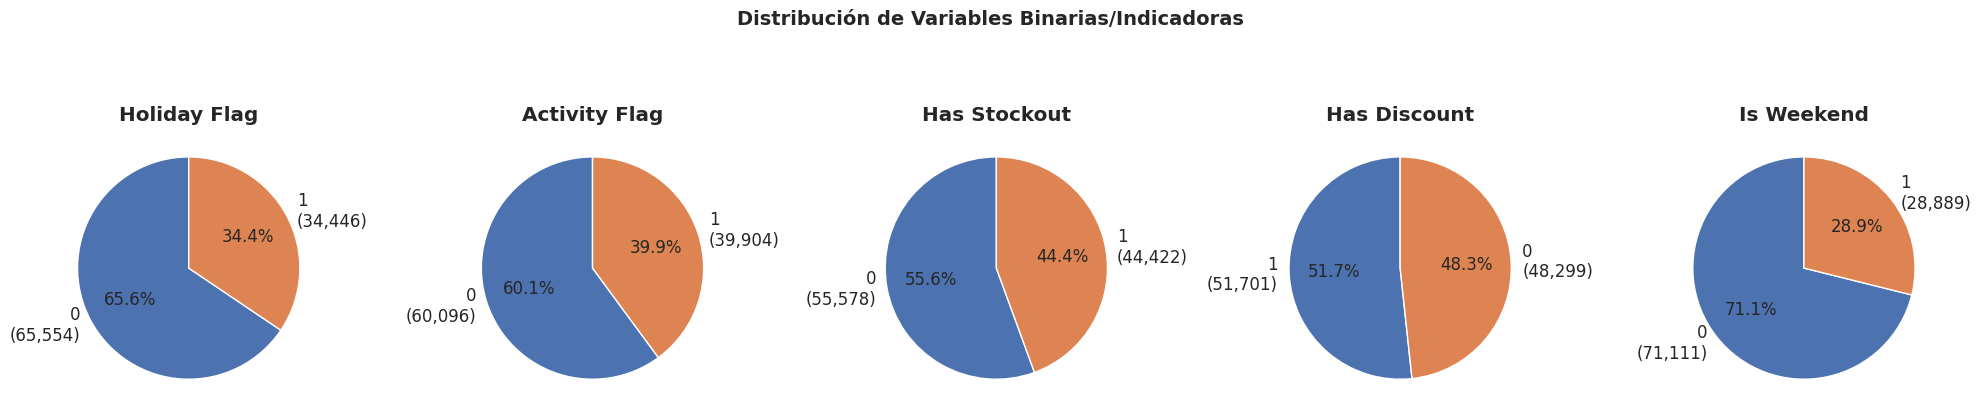

In [ ]:
# ---- 5.1 Variables Categóricas / Indicadoras ----
cat_cols = ['holiday_flag', 'activity_flag', 'has_stockout', 'has_discount', 'is_weekend']

fig, axes = plt.subplots(1, 5, figsize=(20, 5))
for i, col in enumerate(cat_cols):
    counts = df[col].value_counts()
    colors = ['#4C72B0', '#DD8452']
    axes[i].pie(counts, labels=[f'{v}\n({c:,})' for v, c in zip(counts.index, counts)],
               autopct='%1.1f%%', colors=colors, startangle=90)
    axes[i].set_title(col.replace('_', ' ').title(), fontweight='bold')

plt.suptitle('Distribución de Variables Binarias/Indicadoras', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('04_binary_distributions.png', dpi=120, bbox_inches='tight')
plt.show()

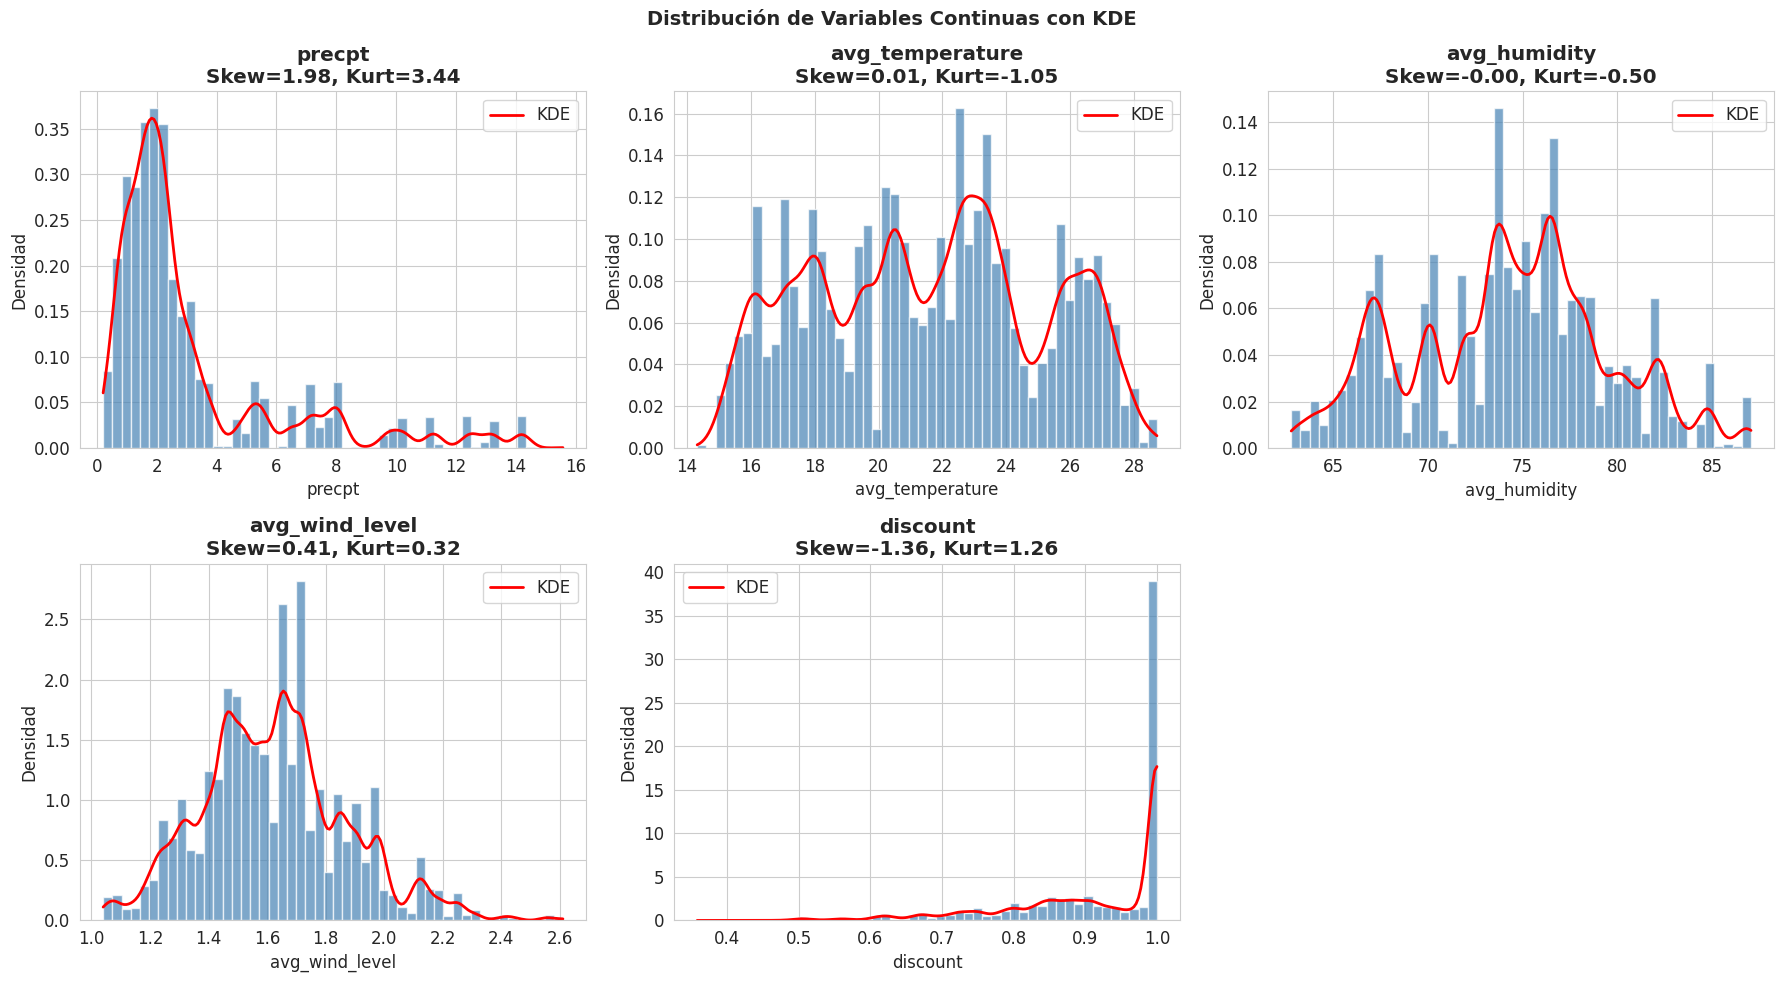

In [ ]:
# ---- 5.2 Distribución de Variables Continuas ----
cont_cols = ['precpt', 'avg_temperature', 'avg_humidity', 'avg_wind_level', 'discount']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cont_cols):
    data = df[col].dropna()
    axes[i].hist(data, bins=50, density=True, alpha=0.7, color='steelblue', edgecolor='white')

    # KDE overlay
    from scipy.stats import gaussian_kde
    kde = gaussian_kde(data)
    x_range = np.linspace(data.min(), data.max(), 200)
    axes[i].plot(x_range, kde(x_range), 'r-', lw=2, label='KDE')

    axes[i].set_title(f'{col}\nSkew={skew(data):.2f}, Kurt={kurtosis(data):.2f}', fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Densidad')
    axes[i].legend()

axes[-1].axis('off')
plt.suptitle('Distribución de Variables Continuas con KDE', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('05_continuous_distributions.png', dpi=120, bbox_inches='tight')
plt.show()

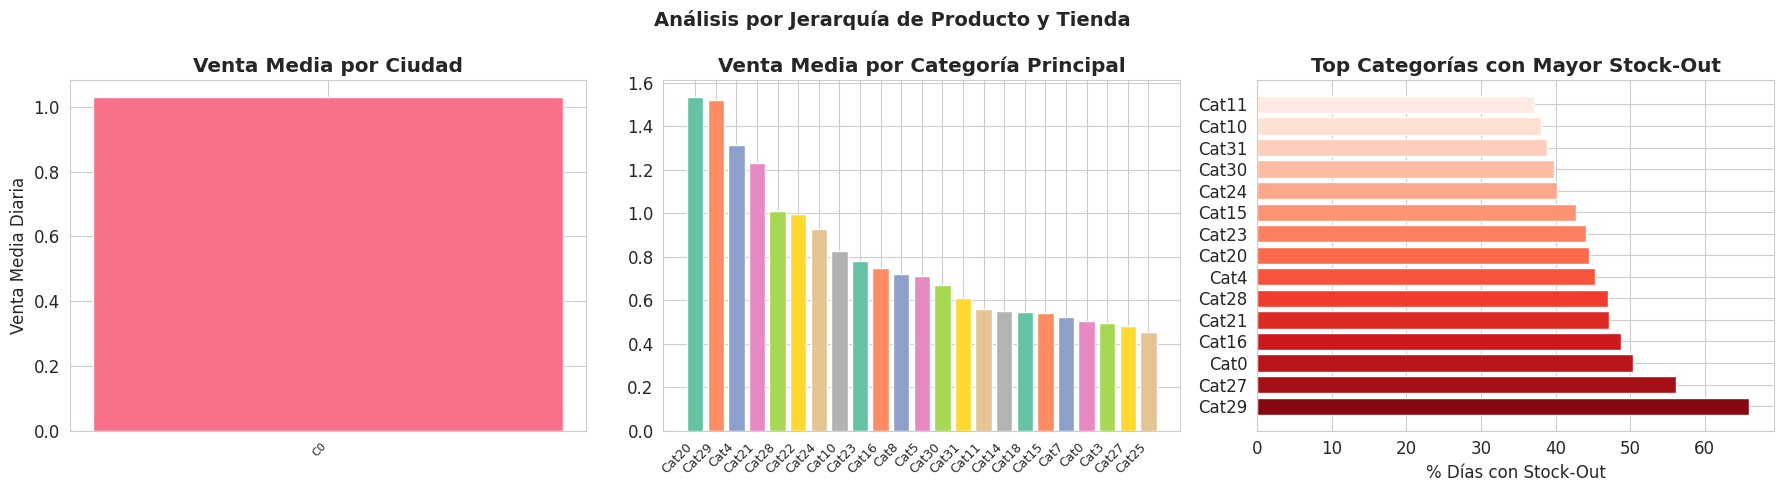

In [ ]:
# ---- 5.3 Distribución jerárquica de categorías ----
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Por ciudad
city_counts = df.groupby('city_id')['sale_amount'].mean().sort_values(ascending=False)
axes[0].bar(range(len(city_counts)), city_counts.values, color=sns.color_palette('husl', len(city_counts)))
axes[0].set_xticks(range(len(city_counts)))
axes[0].set_xticklabels([f'C{c}' for c in city_counts.index], rotation=45, ha='right', fontsize=8)
axes[0].set_title('Venta Media por Ciudad', fontweight='bold')
axes[0].set_ylabel('Venta Media Diaria')

# Por primera categoría
cat1_sales = df.groupby('first_category_id')['sale_amount'].agg(['mean', 'count'])
cat1_sales = cat1_sales[cat1_sales['count'] > 100].sort_values('mean', ascending=False)
axes[1].bar(range(len(cat1_sales)), cat1_sales['mean'].values,
           color=sns.color_palette('Set2', len(cat1_sales)))
axes[1].set_xticks(range(len(cat1_sales)))
axes[1].set_xticklabels([f'Cat{c}' for c in cat1_sales.index], rotation=45, ha='right', fontsize=9)
axes[1].set_title('Venta Media por Categoría Principal', fontweight='bold')

# Stock out por categoría
cat1_stock = df.groupby('first_category_id')['has_stockout'].mean().sort_values(ascending=False)
cat1_stock = cat1_stock.head(15)
axes[2].barh(range(len(cat1_stock)), cat1_stock.values * 100,
            color=sns.color_palette('Reds_r', len(cat1_stock)))
axes[2].set_yticks(range(len(cat1_stock)))
axes[2].set_yticklabels([f'Cat{c}' for c in cat1_stock.index])
axes[2].set_xlabel('% Días con Stock-Out')
axes[2].set_title('Top Categorías con Mayor Stock-Out', fontweight='bold')

plt.suptitle('Análisis por Jerarquía de Producto y Tienda', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('06_hierarchy_analysis.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 6. Análisis Correlacional

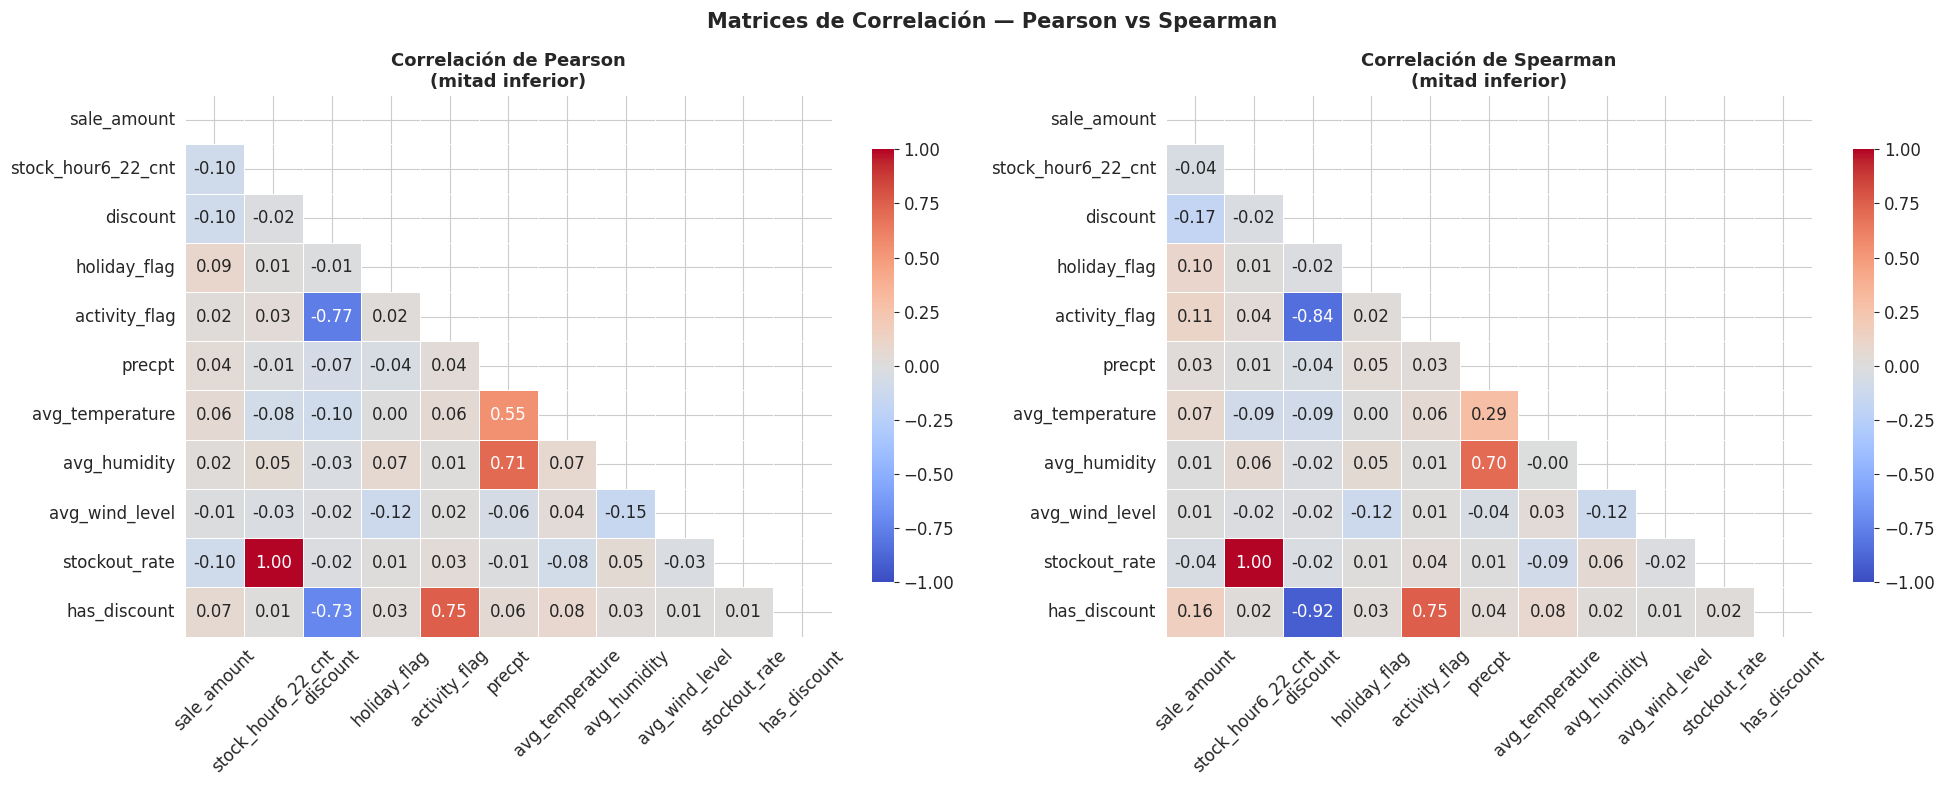

In [ ]:
# ---- 6.1 Matriz de Correlación de Pearson ----
corr_cols = ['sale_amount', 'stock_hour6_22_cnt', 'discount', 'holiday_flag',
             'activity_flag', 'precpt', 'avg_temperature', 'avg_humidity',
             'avg_wind_level', 'stockout_rate', 'has_discount']

corr_matrix = df[corr_cols].corr(method='pearson')

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Pearson
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
           center=0, vmin=-1, vmax=1, ax=axes[0],
           linewidths=0.5, cbar_kws={'shrink': 0.8})
axes[0].set_title('Correlación de Pearson\n(mitad inferior)', fontweight='bold', fontsize=13)
axes[0].tick_params(axis='x', rotation=45)

# Spearman
spearman_matrix = df[corr_cols].corr(method='spearman')
sns.heatmap(spearman_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
           center=0, vmin=-1, vmax=1, ax=axes[1],
           linewidths=0.5, cbar_kws={'shrink': 0.8})
axes[1].set_title('Correlación de Spearman\n(mitad inferior)', fontweight='bold', fontsize=13)
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Matrices de Correlación — Pearson vs Spearman', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('07_correlation_matrices.png', dpi=120, bbox_inches='tight')
plt.show()

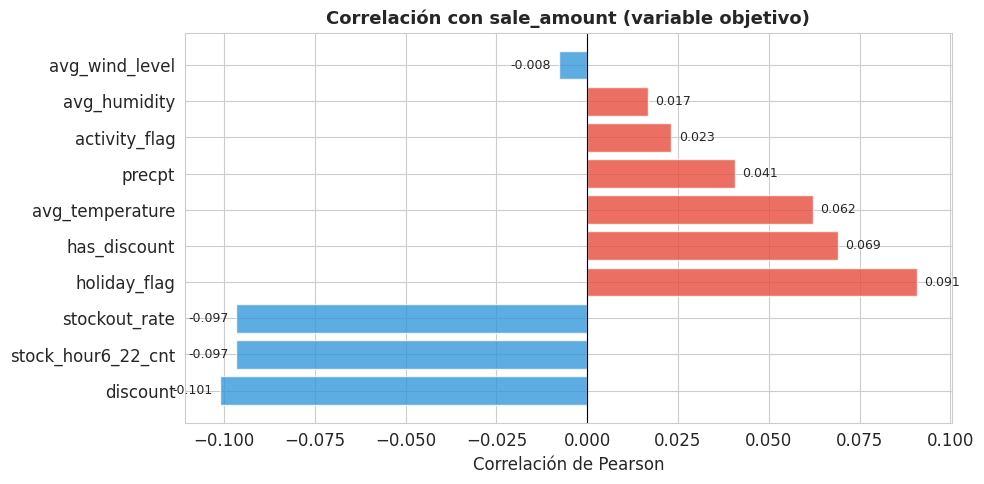


Top correlaciones con sale_amount:
discount             -0.101187
stock_hour6_22_cnt   -0.096596
stockout_rate        -0.096596
holiday_flag          0.090790
has_discount          0.068941
avg_temperature       0.062118
precpt                0.040666
activity_flag         0.023171
avg_humidity          0.016664
avg_wind_level       -0.007900
Name: sale_amount, dtype: float64


In [ ]:
# ---- 6.2 Top correlaciones con sale_amount ----
target_corr = corr_matrix['sale_amount'].drop('sale_amount').sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#e74c3c' if v > 0 else '#3498db' for v in target_corr.values]
bars = ax.barh(range(len(target_corr)), target_corr.values, color=colors, alpha=0.8, edgecolor='white')
ax.set_yticks(range(len(target_corr)))
ax.set_yticklabels(target_corr.index)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Correlación de Pearson')
ax.set_title('Correlación con sale_amount (variable objetivo)', fontweight='bold', fontsize=13)

for bar, val in zip(bars, target_corr.values):
    ax.text(val + 0.002 if val >= 0 else val - 0.002, bar.get_y() + bar.get_height()/2,
           f'{val:.3f}', va='center', ha='left' if val >= 0 else 'right', fontsize=9)

plt.tight_layout()
plt.savefig('08_target_correlations.png', dpi=120, bbox_inches='tight')
plt.show()

print('\nTop correlaciones con sale_amount:')
print(target_corr)

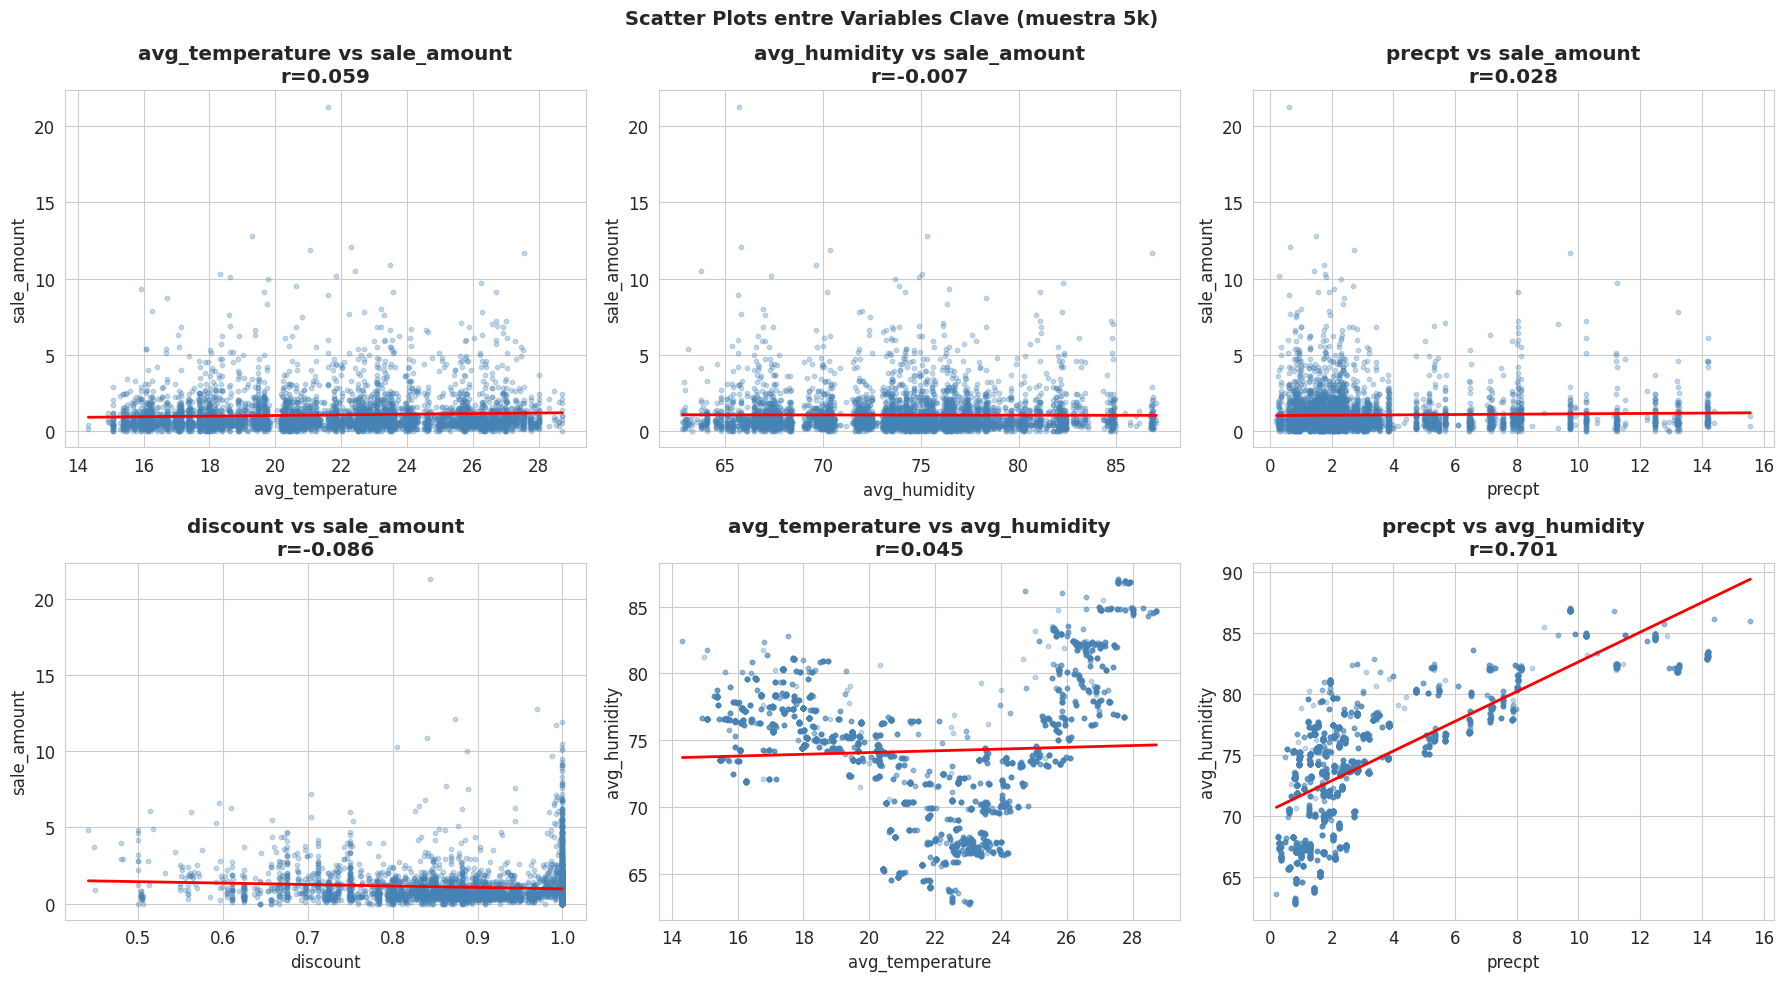

In [ ]:
# ---- 6.3 Scatter plots entre variables clave ----
pairs = [
    ('avg_temperature', 'sale_amount'),
    ('avg_humidity', 'sale_amount'),
    ('precpt', 'sale_amount'),
    ('discount', 'sale_amount'),
    ('avg_temperature', 'avg_humidity'),
    ('precpt', 'avg_humidity'),
]

sample = df.sample(min(5000, len(df)), random_state=SEED)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, (x_col, y_col) in enumerate(pairs):
    r, p = pearsonr(sample[x_col].fillna(0), sample[y_col].fillna(0))
    axes[i].scatter(sample[x_col], sample[y_col], alpha=0.3, s=10, c='steelblue')

    # Línea de regresión
    z = np.polyfit(sample[x_col].fillna(0), sample[y_col].fillna(0), 1)
    p_fn = np.poly1d(z)
    x_line = np.linspace(sample[x_col].min(), sample[x_col].max(), 100)
    axes[i].plot(x_line, p_fn(x_line), 'r-', lw=2)

    axes[i].set_xlabel(x_col)
    axes[i].set_ylabel(y_col)
    axes[i].set_title(f'{x_col} vs {y_col}\nr={r:.3f}', fontweight='bold')

plt.suptitle('Scatter Plots entre Variables Clave (muestra 5k)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('09_scatter_plots.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 7. Análisis Temporal (Series de Tiempo)

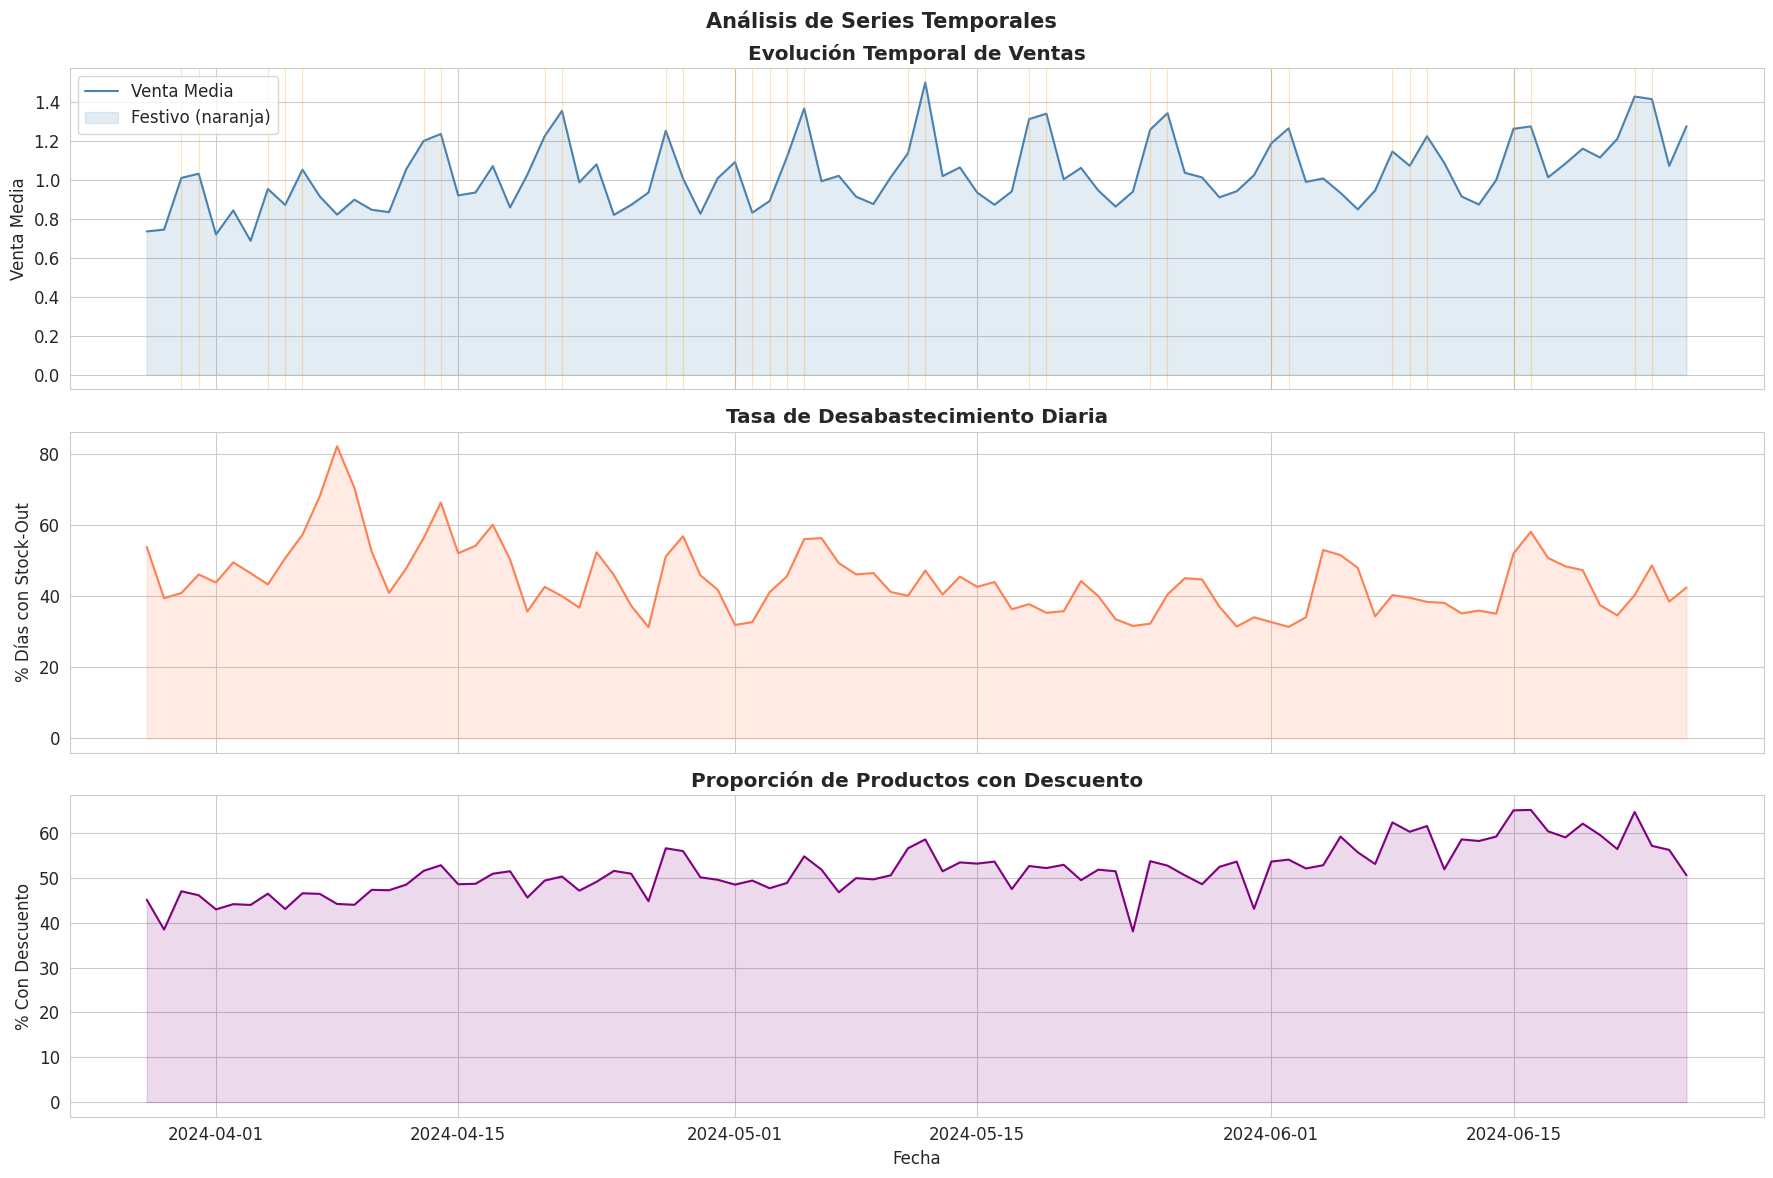

In [ ]:
# ---- 7.1 Ventas diarias agregadas ----
daily_agg = df.groupby('dt').agg(
    sale_mean=('sale_amount', 'mean'),
    sale_sum=('sale_amount', 'sum'),
    stockout_rate=('has_stockout', 'mean'),
    discount_rate=('has_discount', 'mean'),
    holiday=('holiday_flag', 'first'),
    activity=('activity_flag', 'first'),
).reset_index()

fig, axes = plt.subplots(3, 1, figsize=(18, 12), sharex=True)

# Ventas
axes[0].plot(daily_agg['dt'], daily_agg['sale_mean'], color='steelblue', lw=1.5, label='Media diaria')
axes[0].fill_between(daily_agg['dt'], daily_agg['sale_mean'], alpha=0.15, color='steelblue')
# Destacar festivos
holiday_dates = daily_agg[daily_agg['holiday'] == 1]['dt']
for d in holiday_dates:
    axes[0].axvline(d, color='orange', alpha=0.3, lw=0.8)
axes[0].set_ylabel('Venta Media')
axes[0].set_title('Evolución Temporal de Ventas', fontweight='bold')
axes[0].legend(['Venta Media', 'Festivo (naranja)'])

# Stock-out rate
axes[1].plot(daily_agg['dt'], daily_agg['stockout_rate'] * 100, color='coral', lw=1.5)
axes[1].fill_between(daily_agg['dt'], daily_agg['stockout_rate'] * 100, alpha=0.15, color='coral')
axes[1].set_ylabel('% Días con Stock-Out')
axes[1].set_title('Tasa de Desabastecimiento Diaria', fontweight='bold')

# Descuento
axes[2].plot(daily_agg['dt'], daily_agg['discount_rate'] * 100, color='purple', lw=1.5)
axes[2].fill_between(daily_agg['dt'], daily_agg['discount_rate'] * 100, alpha=0.15, color='purple')
axes[2].set_ylabel('% Con Descuento')
axes[2].set_xlabel('Fecha')
axes[2].set_title('Proporción de Productos con Descuento', fontweight='bold')

plt.suptitle('Análisis de Series Temporales', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('10_time_series.png', dpi=120, bbox_inches='tight')
plt.show()

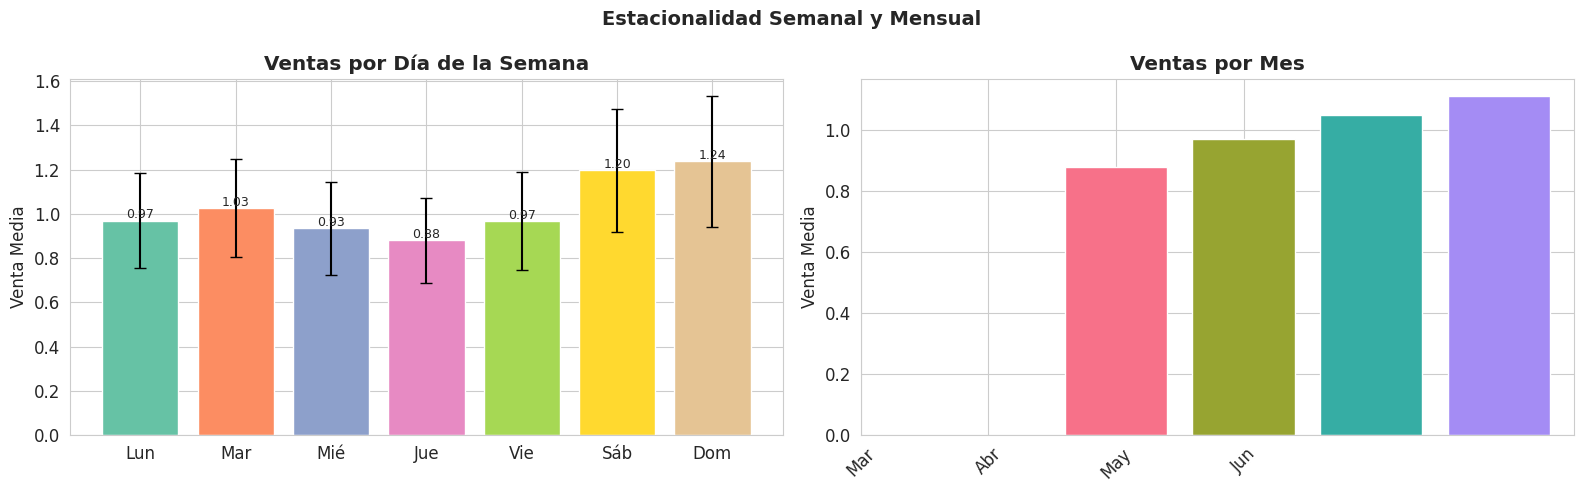

In [ ]:
# ---- 7.2 Estacionalidad semanal y mensual ----
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Por día de semana
day_names = ['Lun', 'Mar', 'Mié', 'Jue', 'Vie', 'Sáb', 'Dom']
weekly = df.groupby('day_of_week')['sale_amount'].agg(['mean', 'std'])
axes[0].bar(range(7), weekly['mean'], yerr=weekly['std'] * 0.2,
           color=sns.color_palette('Set2', 7), capsize=4, edgecolor='white')
axes[0].set_xticks(range(7))
axes[0].set_xticklabels(day_names)
axes[0].set_title('Ventas por Día de la Semana', fontweight='bold')
axes[0].set_ylabel('Venta Media')
for i, (mu, _) in enumerate(weekly.values):
    axes[0].text(i, mu + 0.01, f'{mu:.2f}', ha='center', fontsize=9)

# Por mes
monthly = df.groupby('month')['sale_amount'].mean()
month_names = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']
axes[1].bar(monthly.index - 1, monthly.values,
           color=sns.color_palette('husl', len(monthly)), edgecolor='white')
axes[1].set_xticks(range(len(monthly)))
axes[1].set_xticklabels([month_names[m-1] for m in monthly.index], rotation=45)
axes[1].set_title('Ventas por Mes', fontweight='bold')
axes[1].set_ylabel('Venta Media')

plt.suptitle('Estacionalidad Semanal y Mensual', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('11_seasonality.png', dpi=120, bbox_inches='tight')
plt.show()

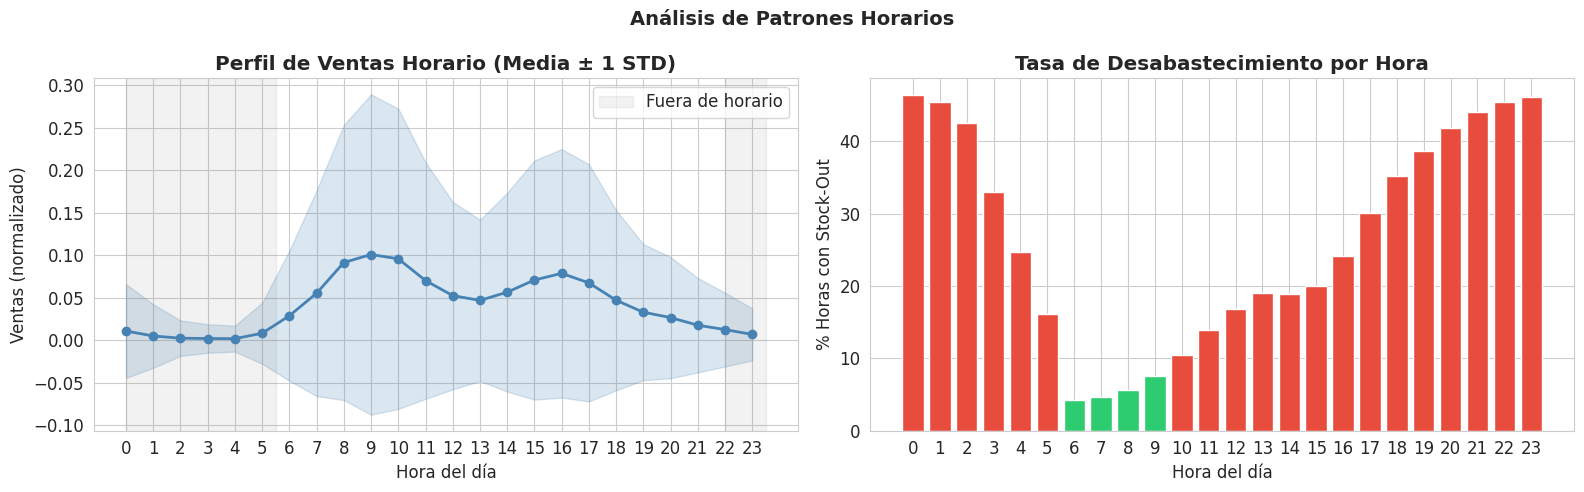

In [ ]:
# ---- 7.3 Análisis de horas de venta (sequences) ----
# Extraer el vector de ventas horarias de la muestra
hourly_matrix = np.array([list(row) for row in df['hours_sale'].iloc[:10000]])
hourly_mean = hourly_matrix.mean(axis=0)
hourly_std  = hourly_matrix.std(axis=0)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

hours = list(range(24))
axes[0].plot(hours, hourly_mean, 'o-', color='steelblue', lw=2, markersize=6)
axes[0].fill_between(hours,
                     hourly_mean - hourly_std,
                     hourly_mean + hourly_std,
                     alpha=0.2, color='steelblue')
axes[0].set_xlabel('Hora del día')
axes[0].set_ylabel('Ventas (normalizado)')
axes[0].set_title('Perfil de Ventas Horario (Media ± 1 STD)', fontweight='bold')
axes[0].set_xticks(hours)
axes[0].axvspan(22, 23.5, alpha=0.1, color='gray', label='Fuera de horario')
axes[0].axvspan(0, 5.5, alpha=0.1, color='gray')
axes[0].legend()

# Stock status
stock_matrix = np.array([list(row) for row in df['hours_stock_status'].iloc[:10000]])
stock_mean = stock_matrix.mean(axis=0) * 100
axes[1].bar(hours, stock_mean, color=['#e74c3c' if v > 10 else '#2ecc71' for v in stock_mean],
           edgecolor='white')
axes[1].set_xlabel('Hora del día')
axes[1].set_ylabel('% Horas con Stock-Out')
axes[1].set_title('Tasa de Desabastecimiento por Hora', fontweight='bold')
axes[1].set_xticks(hours)

plt.suptitle('Análisis de Patrones Horarios', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('12_hourly_patterns.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 8. Análisis de Variables Climáticas y su Impacto

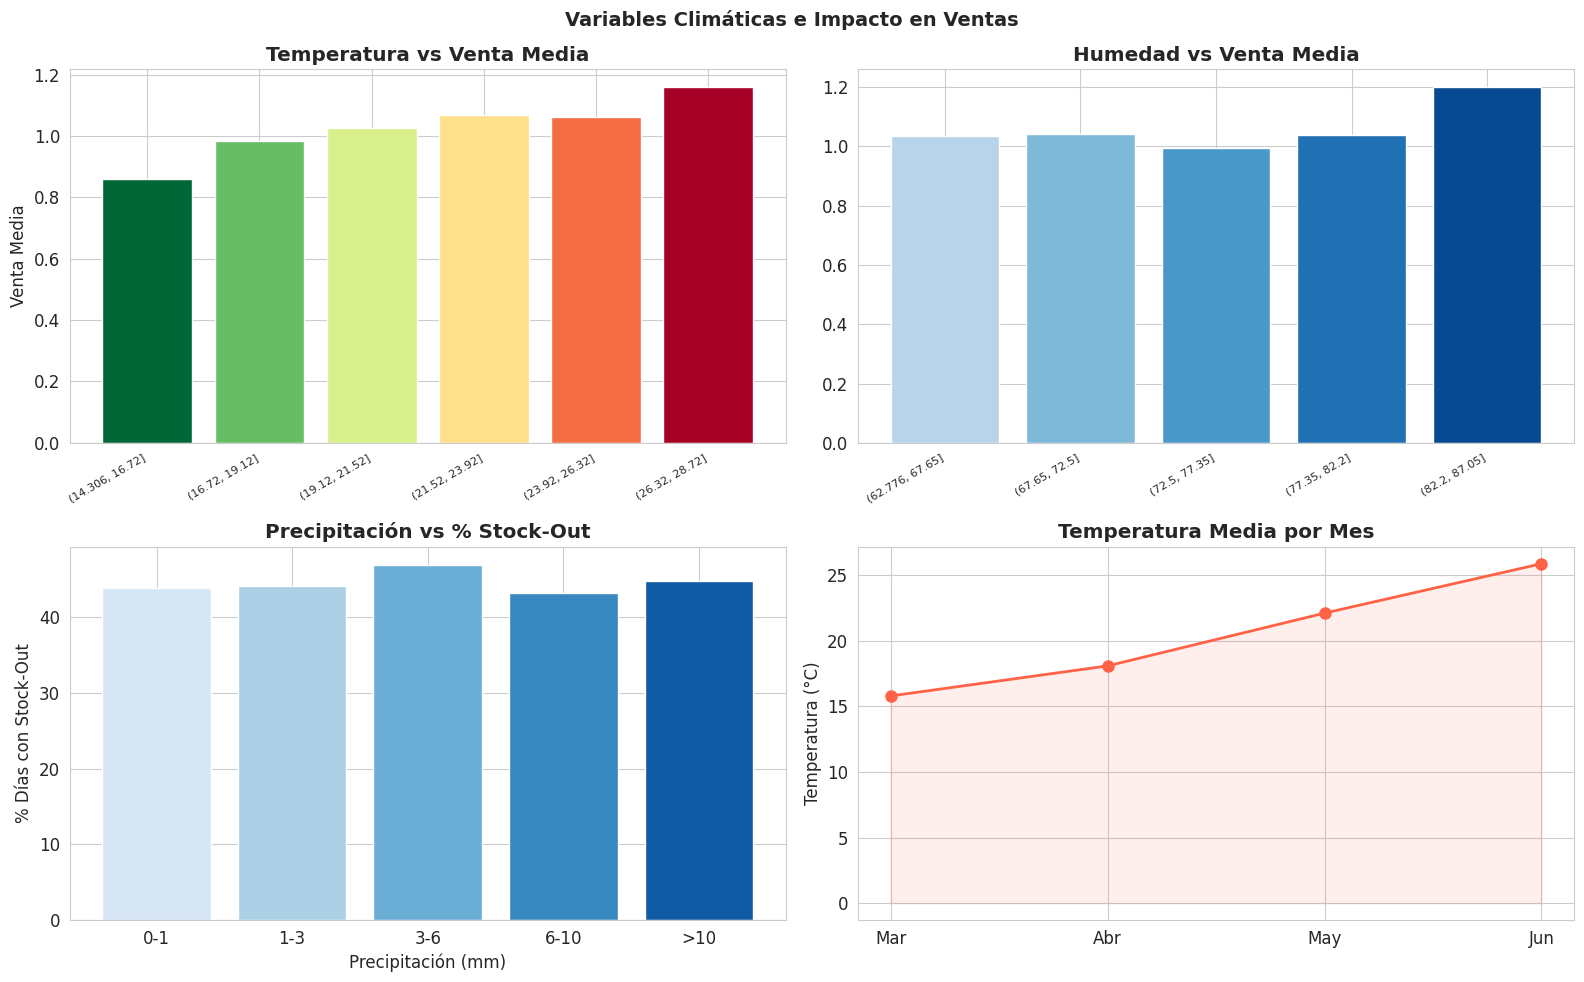

In [ ]:
# ---- 8.1 Clima vs Ventas por rangos ----
df['temp_bin'] = pd.cut(df['avg_temperature'], bins=6)
df['humidity_bin'] = pd.cut(df['avg_humidity'], bins=5)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Temperatura vs ventas
temp_sale = df.groupby('temp_bin')['sale_amount'].mean().reset_index()
axes[0, 0].bar(range(len(temp_sale)), temp_sale['sale_amount'],
              color=plt.cm.RdYlGn_r(np.linspace(0, 1, len(temp_sale))), edgecolor='white')
axes[0, 0].set_xticks(range(len(temp_sale)))
axes[0, 0].set_xticklabels([str(b) for b in temp_sale['temp_bin']], rotation=30, ha='right', fontsize=8)
axes[0, 0].set_title('Temperatura vs Venta Media', fontweight='bold')
axes[0, 0].set_ylabel('Venta Media')

# Humedad vs ventas
hum_sale = df.groupby('humidity_bin')['sale_amount'].mean().reset_index()
axes[0, 1].bar(range(len(hum_sale)), hum_sale['sale_amount'],
              color=plt.cm.Blues(np.linspace(0.3, 0.9, len(hum_sale))), edgecolor='white')
axes[0, 1].set_xticks(range(len(hum_sale)))
axes[0, 1].set_xticklabels([str(b) for b in hum_sale['humidity_bin']], rotation=30, ha='right', fontsize=8)
axes[0, 1].set_title('Humedad vs Venta Media', fontweight='bold')

# Precipitación vs stock-out
df['precpt_bin'] = pd.cut(df['precpt'], bins=[0, 1, 3, 6, 10, df['precpt'].max() + 1],
                         labels=['0-1', '1-3', '3-6', '6-10', '>10'])
precpt_stock = df.groupby('precpt_bin', observed=True)['has_stockout'].mean() * 100
axes[1, 0].bar(range(len(precpt_stock)), precpt_stock.values,
              color=sns.color_palette('Blues', len(precpt_stock)), edgecolor='white')
axes[1, 0].set_xticks(range(len(precpt_stock)))
axes[1, 0].set_xticklabels(precpt_stock.index)
axes[1, 0].set_title('Precipitación vs % Stock-Out', fontweight='bold')
axes[1, 0].set_ylabel('% Días con Stock-Out')
axes[1, 0].set_xlabel('Precipitación (mm)')

# Temperatura por mes (heatmap)
temp_month = df.groupby('month')['avg_temperature'].mean()
month_names_short = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']
axes[1, 1].plot(temp_month.index, temp_month.values, 'o-', color='tomato', lw=2, markersize=8)
axes[1, 1].fill_between(temp_month.index, temp_month.values, alpha=0.1, color='tomato')
axes[1, 1].set_xticks(temp_month.index)
axes[1, 1].set_xticklabels([month_names_short[m-1] for m in temp_month.index])
axes[1, 1].set_title('Temperatura Media por Mes', fontweight='bold')
axes[1, 1].set_ylabel('Temperatura (°C)')

plt.suptitle('Variables Climáticas e Impacto en Ventas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('13_climate_impact.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 9. Análisis de Stock-Outs (Desabastecimiento)

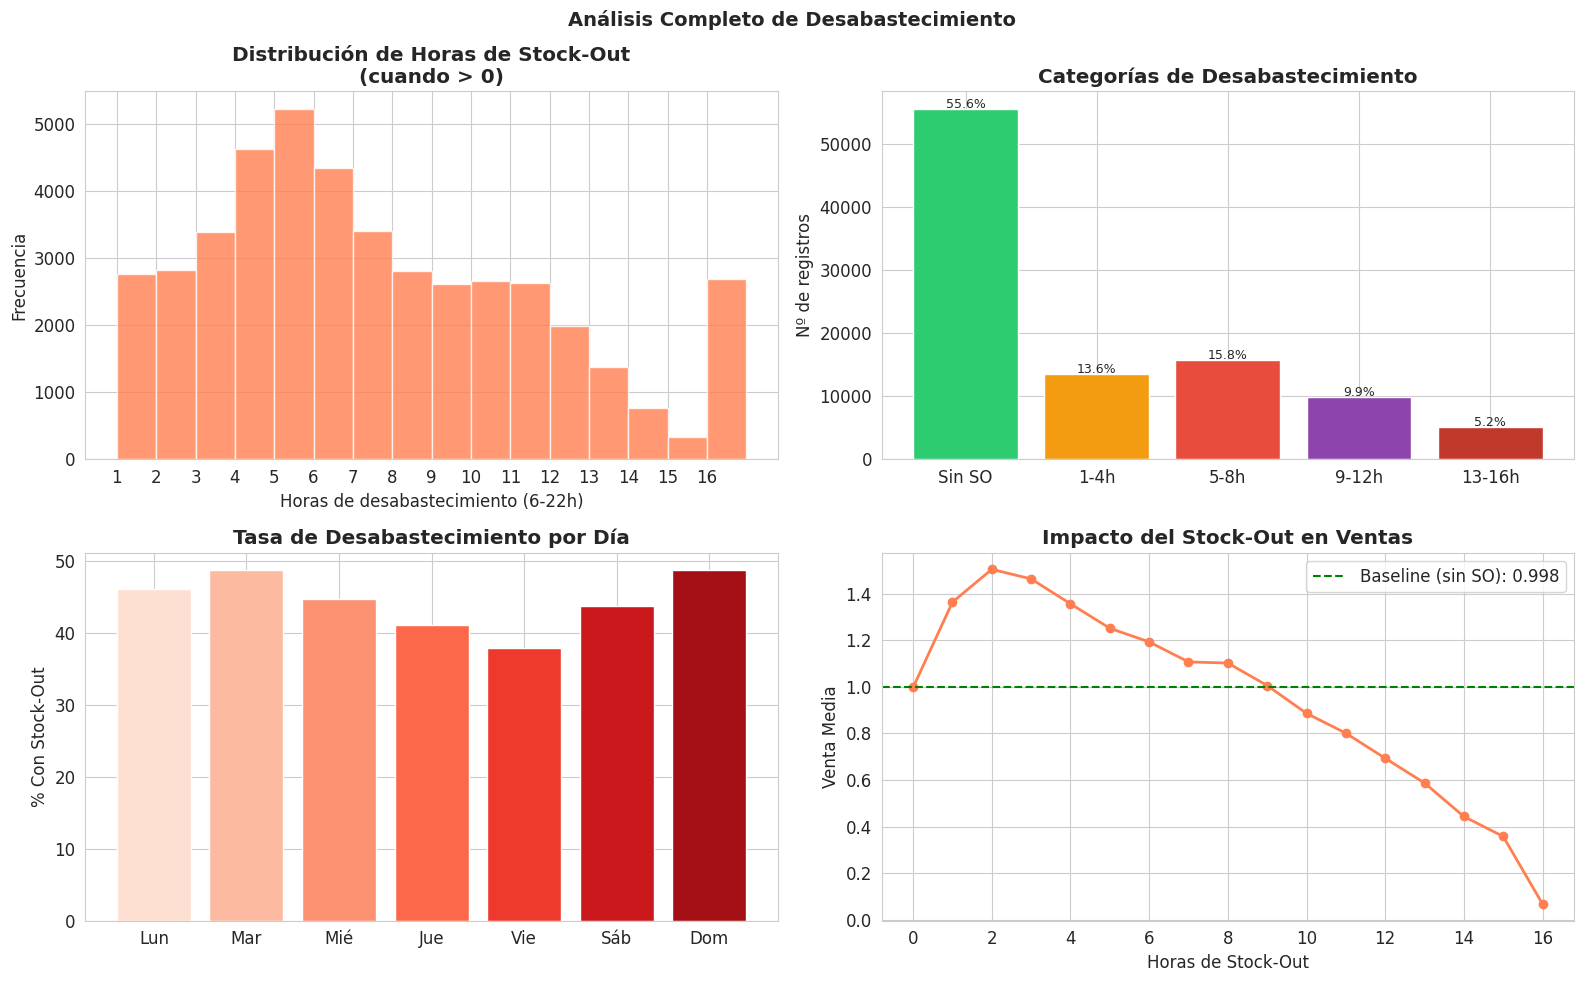


Estadísticas de Desabastecimiento:
% registros con algún SO:    44.4%
% SO completo (16h):         2.7%
Horas SO media (cuando > 0): 7.1h


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Distribución de horas de stock-out
so_data = df[df['stock_hour6_22_cnt'] > 0]['stock_hour6_22_cnt']
axes[0, 0].hist(so_data, bins=16, range=(1, 17), color='coral', edgecolor='white', alpha=0.8)
axes[0, 0].set_xlabel('Horas de desabastecimiento (6-22h)')
axes[0, 0].set_ylabel('Frecuencia')
axes[0, 0].set_title('Distribución de Horas de Stock-Out\n(cuando > 0)', fontweight='bold')
axes[0, 0].set_xticks(range(1, 17))

# Stock-out completo vs parcial
so_cats = pd.cut(df['stock_hour6_22_cnt'],
                bins=[-1, 0, 4, 8, 12, 16],
                labels=['Sin SO', '1-4h', '5-8h', '9-12h', '13-16h'])
so_dist = so_cats.value_counts().sort_index()
axes[0, 1].bar(range(len(so_dist)), so_dist.values,
              color=['#2ecc71', '#f39c12', '#e74c3c', '#8e44ad', '#c0392b'], edgecolor='white')
axes[0, 1].set_xticks(range(len(so_dist)))
axes[0, 1].set_xticklabels(so_dist.index)
axes[0, 1].set_title('Categorías de Desabastecimiento', fontweight='bold')
axes[0, 1].set_ylabel('Nº de registros')
for j, v in enumerate(so_dist.values):
    axes[0, 1].text(j, v + 100, f'{v/len(df)*100:.1f}%', ha='center', fontsize=9)

# Stock-out por día de semana
so_weekly = df.groupby('day_of_week')['has_stockout'].mean() * 100
axes[1, 0].bar(range(7), so_weekly.values,
              color=sns.color_palette('Reds', 7), edgecolor='white')
axes[1, 0].set_xticks(range(7))
axes[1, 0].set_xticklabels(day_names)
axes[1, 0].set_title('Tasa de Desabastecimiento por Día', fontweight='bold')
axes[1, 0].set_ylabel('% Con Stock-Out')

# Stock-out y ventas perdidas estimadas
# Ventas en días sin SO como baseline
baseline = df[df['has_stockout'] == 0]['sale_amount'].mean()
so_impact = df.groupby('stock_hour6_22_cnt')['sale_amount'].mean()
axes[1, 1].plot(so_impact.index, so_impact.values, 'o-', color='coral', lw=2)
axes[1, 1].axhline(baseline, color='green', linestyle='--', label=f'Baseline (sin SO): {baseline:.3f}')
axes[1, 1].set_xlabel('Horas de Stock-Out')
axes[1, 1].set_ylabel('Venta Media')
axes[1, 1].set_title('Impacto del Stock-Out en Ventas', fontweight='bold')
axes[1, 1].legend()

plt.suptitle('Análisis Completo de Desabastecimiento', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('15_stockout_analysis.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'\nEstadísticas de Desabastecimiento:')
print(f'% registros con algún SO:    {df["has_stockout"].mean()*100:.1f}%')
print(f'% SO completo (16h):         {(df["stock_hour6_22_cnt"]==16).mean()*100:.1f}%')
print(f'Horas SO media (cuando > 0): {df[df["stock_hour6_22_cnt"]>0]["stock_hour6_22_cnt"].mean():.1f}h')

---
## 10. Resumen y Hallazgos Clave

In [ ]:
print('='*70)
print('RESUMEN DE HALLAZGOS — FreshRetailNet-50K EDA')
print('='*70)

print(f'''
ESTRUCTURA DEL DATASET
   • {df_train.shape[0]:,} filas en train | {df_eval.shape[0]:,} en eval
   • 19 variables: 7 IDs jerárquicos, 1 fecha, 6 numéricas, 2 secuencias, 3 binarias
   • Cobertura: {df["dt"].min().date()} a {df["dt"].max().date()}

VALORES FALTANTES
   • No se detectan valores nulos en columnas escalares
   • Dataset limpio y completo en las variables numéricas clave

OUTLIERS
   • sale_amount: alta asimetría positiva (cola derecha larga)
   • precpt: >90% son ceros, con casos extremos de precipitación alta
   • stock_hour6_22_cnt: bimodal (0 = normal, 16 = desabastecimiento total)
   • discount: concentrado en 0.5, 0.75, 0.8, 0.9, 1.0 (valores discretos)

DISTRIBUCIONES
   • sale_amount sigue distribución exponencial / Poisson mezclada
   • avg_temperature: distribución normal-ish, varía ~15-28°C
   • avg_humidity: relativamente uniforme entre 60-85%
   • ~{df["has_discount"].mean()*100:.0f}% de registros tienen algún tipo de descuento
   • ~{df["holiday_flag"].mean()*100:.0f}% de días son festivos
   • ~{df["activity_flag"].mean()*100:.0f}% tienen actividad comercial activa

CORRELACIONES
   • sale_amount muestra correlación positiva moderada con avg_temperature
   • stock_hour6_22_cnt correlaciona negativamente con sale_amount (demanda censurada)
   • avg_temperature y avg_humidity tienen correlación negativa (más calor = menos humedad)
   • precpt y avg_humidity correlacionan positivamente
   • discount no tiene correlación lineal fuerte con ventas (efecto no-lineal)

TEMPORALIDAD
   • Patrón estacional claro: ventas crecen con el calor (primavera-verano)
   • Pico de ventas en horas 7-14 (mañana/mediodía)
   • Fines de semana no muestran diferencia dramática vs días laborables
   • Festivos y actividades comerciales aumentan ventas significativamente

DESABASTECIMIENTO
   • ~{df["has_stockout"].mean()*100:.1f}% de registros tienen algún stock-out (orgánico ~20%)
   • El stock-out reduce ventas observables (demanda censurada)
   • Mayor SO en horas nocturnas/madrugada (fuera de ventana de reabastecimiento)
   • SO completo (16h) afecta al {(df["stock_hour6_22_cnt"]==16).mean()*100:.1f}% de registros

IMPLICACIONES PARA MODELADO
   • Necesidad de modelos de demanda censurada (Tobit, survival analysis)
   • Features climáticas relevantes especialmente temperatura y precipitación
   • La estacionalidad y los festivos son señales importantes
   • La distribución de ventas requiere transformación log o modelo con sesgo positivo
   • Las series horarias aportan información granular valiosa
''')
print('='*70)

RESUMEN DE HALLAZGOS — FreshRetailNet-50K EDA

ESTRUCTURA DEL DATASET
   • 100,000 filas en train | 350,000 en eval
   • 19 variables: 7 IDs jerárquicos, 1 fecha, 6 numéricas, 2 secuencias, 3 binarias
   • Cobertura: 2024-03-28 a 2024-06-25

VALORES FALTANTES
   • No se detectan valores nulos en columnas escalares
   • Dataset limpio y completo en las variables numéricas clave

OUTLIERS
   • sale_amount: alta asimetría positiva (cola derecha larga)
   • precpt: >90% son ceros, con casos extremos de precipitación alta
   • stock_hour6_22_cnt: bimodal (0 = normal, 16 = desabastecimiento total)
   • discount: concentrado en 0.5, 0.75, 0.8, 0.9, 1.0 (valores discretos)

DISTRIBUCIONES
   • sale_amount sigue distribución exponencial / Poisson mezclada
   • avg_temperature: distribución normal-ish, varía ~15-28°C
   • avg_humidity: relativamente uniforme entre 60-85%
   • ~52% de registros tienen algún tipo de descuento
   • ~34% de días son festivos
   • ~40% tienen actividad comercial acti

In [ ]:
print('\nAnálisis EDA completado exitosamente!')
print('Archivos generados:')
import os
for f in sorted(os.listdir('.')):
    if f.endswith('.png'):
        print(f'   {f}')


Análisis EDA completado exitosamente!
Archivos generados:
   00_eda_dashboard.png
   01_missing_values.png
   02_outliers_boxplots.png
   03_sale_amount_distribution.png
   04_binary_distributions.png
   05_continuous_distributions.png
   06_hierarchy_analysis.png
   07_correlation_matrices.png
   08_target_correlations.png
   09_scatter_plots.png
   10_time_series.png
   11_seasonality.png
   12_hourly_patterns.png
   13_climate_impact.png
   14_discount_holiday_analysis.png
   15_stockout_analysis.png
